In [12]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import xarray as xr
import geopandas as gpd
import cartopy.crs as ccrs

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size' : 18})

# Functions

# Load in Data

In [13]:
# Define filepaths
root_dir = Path().resolve().parents[0]
wrf_fpath = root_dir / 'data' / 'wrf' / 'wrf-fog-cldfra.nc'
met_fpath = root_dir / 'data' / 'weather-station' / 'sci-fog-analysis' / 'combined-sites.csv'
station_fpath = root_dir / 'data' / 'geospatial' / 'sci-weather-stations' / 'sci-stations.shp'

## Load in WRF Data
wrf_fog_ds = xr.open_dataset(wrf_fpath)
#wrf_fog_ds = wrf_fog_ds.rename({'__xarray_dataarray_variable__' : 'fog-cldfra'})

# Remove duplicates
wrf_fog_ds = wrf_fog_ds.groupby('time').mean()

# Create binary fog/no fog based on previously identified threshold
wrf_fog_ds['wrf-fog-binary'] = xr.where(wrf_fog_ds['fog-cldfra'] > .125, 1, 0)

## Load in Weather Station Locations
station_gdf = gpd.read_file(station_fpath)

## Load in Weather Station Data
met_df = pd.read_csv(met_fpath, index_col=0)
met_df['time (PST)'] = pd.to_datetime(met_df['time (PST)'])
met_df['time (PST)'] = met_df['time (PST)'] - pd.to_timedelta(1, unit='h')
met_df = met_df.loc[met_df['time (PST)'].dt.month.isin([5,6,7,8,9])]
met_df = met_df.loc[~met_df['site'].isin(['eend'])]  # Remove sties with very low observation counts
met_df = met_df.set_index(['site', 'time (PST)'])


# Subset and resample to match WRF hourly timestep
met_fog = met_df[['fog']]
met_fog = met_fog.groupby(['site', pd.Grouper(freq='h', level='time (PST)')]).sum()
met_fog['fog-binary'] = met_fog['fog'].apply(lambda x: 1 if x > 0 else 0)
met_fog.head()



fog  fog-binary
site time (PST)                          
cair 2004-05-01 00:00:00  0.0           0
     2004-05-01 01:00:00  0.0           0
     2004-05-01 02:00:00  0.0           0
     2004-05-01 03:00:00  0.0           0
     2004-05-01 04:00:00  0.0           0

# Visualize WRF Fog Patterns

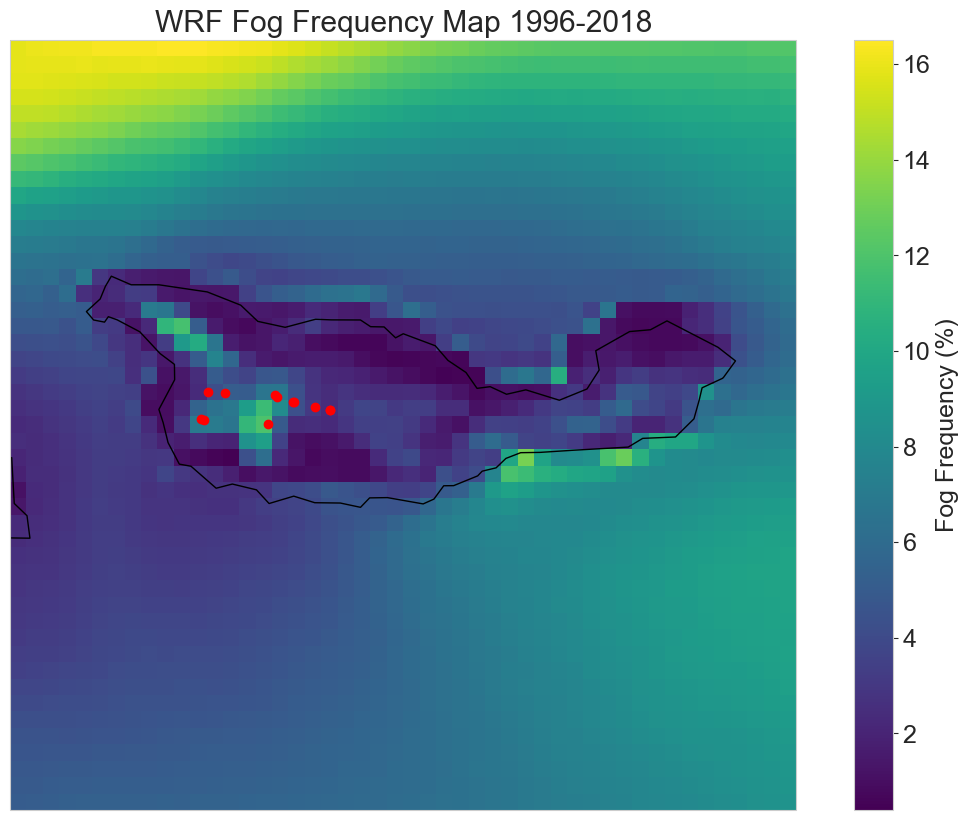

In [14]:
min_year = int(wrf_fog_ds['time'].min().dt.year)
max_year = int(wrf_fog_ds['time'].max().dt.year)

ds_gp = wrf_fog_ds['wrf-fog-binary'].sum('time')
ds_gp_count = wrf_fog_ds['wrf-fog-binary'].count('time')
ds_gp = ds_gp / ds_gp_count * 100

fig, ax = plt.subplots(figsize=(15,10), subplot_kw={'projection' : ccrs.PlateCarree()})
ds_gp.plot(ax=ax, cbar_kwargs={"label" : "Fog Frequency (%)"})
ax.coastlines()
station_gdf.plot(ax=ax, color='red')  # Plo station coords
ax.set(title=f'WRF Fog Frequency Map {min_year}-{max_year}')

plt.show()

# Extract WRF values for each site

In [15]:
# Extract WRF data for each site
wrf_fog_df = pd.DataFrame()
for i, row in station_gdf.iterrows():
    wrf_station_df = wrf_fog_ds.sel(lat=row['latitude'], lon=row['longitude'], method='nearest')
    wrf_station_df = wrf_station_df.to_dataframe().drop(['lat', 'lon'], axis=1)
    wrf_station_df['site'] = row['station']
    wrf_fog_df = pd.concat([wrf_fog_df, wrf_station_df])

wrf_fog_df = wrf_fog_df.reset_index().rename({'time' : 'time (PST)'}, axis=1)
wrf_fog_df = wrf_fog_df.set_index(['site', 'time (PST)'])

# Join observed vs. modeled data
join_df = met_fog[['fog', 'fog-binary']].join(wrf_fog_df, how='inner')
join_df.head(2)

fog  fog-binary  fog-cldfra  wrf-fog-binary
site time (PST)                                                      
cair 2004-05-01 00:00:00  0.0           0         0.0               0
     2004-05-01 01:00:00  0.0           0         0.0               0

In [16]:
# Check that it looks as expected
join_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 89016 entries, ('cair', Timestamp('2004-05-01 00:00:00')) to ('wrdg', Timestamp('2006-09-30 16:00:00'))
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fog             89016 non-null  float64
 1   fog-binary      89016 non-null  int64  
 2   fog-cldfra      89016 non-null  float32
 3   wrf-fog-binary  89016 non-null  int64  
dtypes: float32(1), float64(1), int64(2)
memory usage: 8.1+ MB


# Bar Plots

## Overall Frequencies

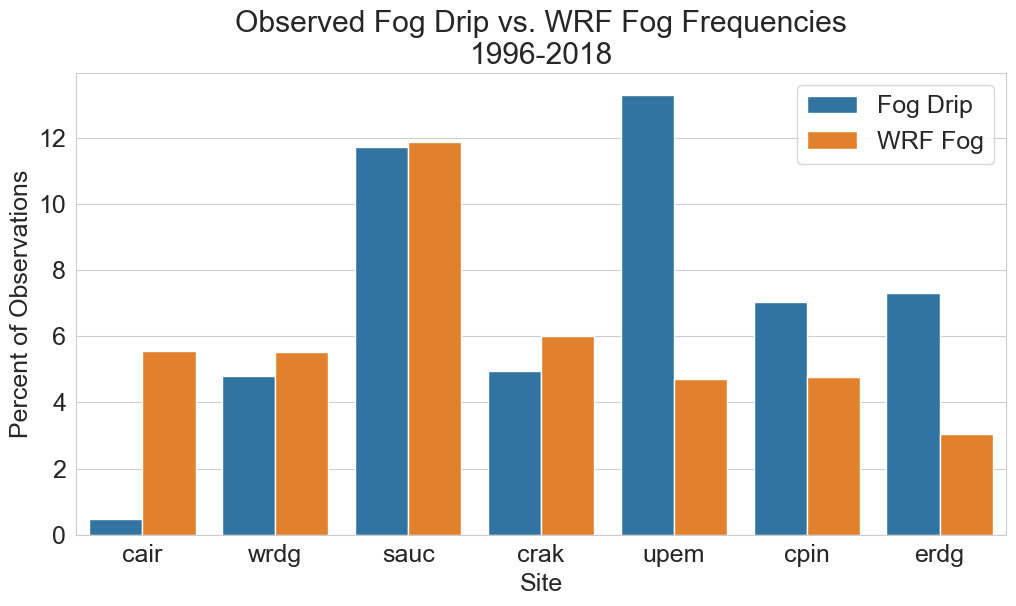

In [17]:
df_gp = join_df[['fog-binary', 'wrf-fog-binary']].groupby('site').sum()
df_count = join_df[['fog-binary', 'wrf-fog-binary']].groupby('site').count()
df_gp = df_gp / df_count * 100
df_gp = df_gp.reset_index()

df_gp = df_gp.melt(id_vars='site', value_vars=['fog-binary', 'wrf-fog-binary'], var_name='source', value_name='count')


# Plot frequencies
site_order = ['cair', 'wrdg', 'sauc', 'crak', 'upem','cpin', 'erdg']  # Ordered West -> East
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(df_gp,
            x='site',
            y='count',
            hue='source',
            order=site_order)
ax.set(title=f'Observed Fog Drip vs. WRF Fog Frequencies\n{min_year}-{max_year}',
       xlabel='Site',
       ylabel='Percent of Observations')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Fog Drip', 'WRF Fog'], title='')

plt.show()

## Annual Frequencies

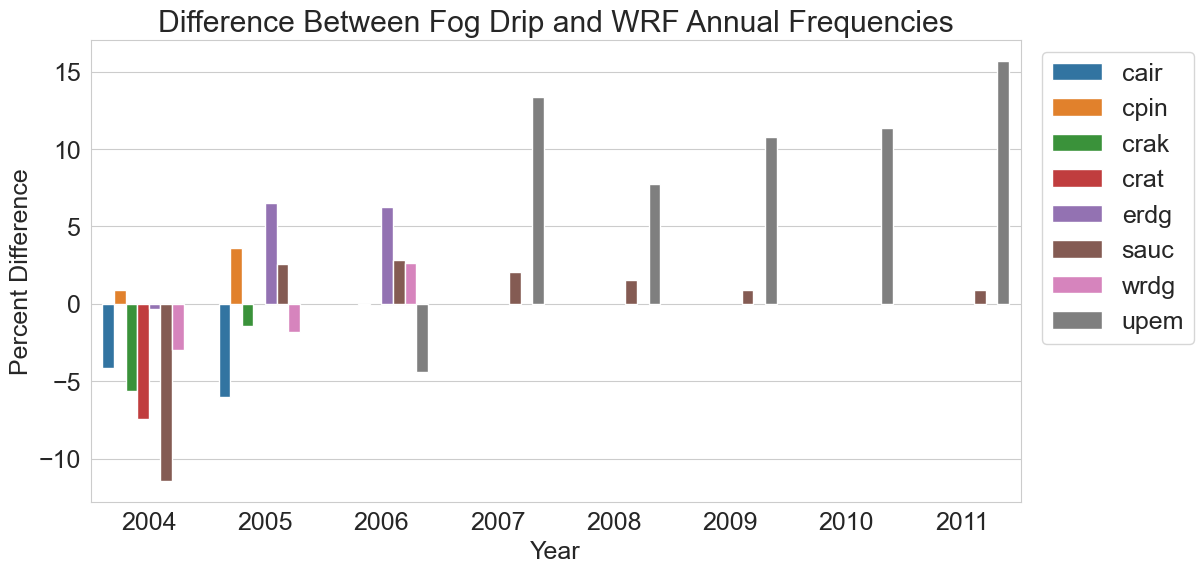

In [18]:
df_gp = join_df.groupby(['site', pd.Grouper(freq='YE', level='time (PST)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='YE', level='time (PST)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp[['fog-binary', 'wrf-fog-binary']].reset_index()
df_gp['year'] = df_gp['time (PST)'].dt.year
df_gp['diff'] = df_gp['fog-binary'] - df_gp['wrf-fog-binary']

df_gp_long = df_gp.melt(id_vars=['site', 'time (PST)'], value_vars=['fog-binary', 'wrf-fog-binary'],
                        var_name='source', value_name='frequency')

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=df_gp,
            x='year',
            y='diff',
            hue='site')
ax.set(title='Difference Between Fog Drip and WRF Annual Frequencies',
       xlabel='Year',
       ylabel='Percent Difference')

plt.legend(title='', loc='upper right', bbox_to_anchor=(1.2,1))

plt.show()

# Time Series 

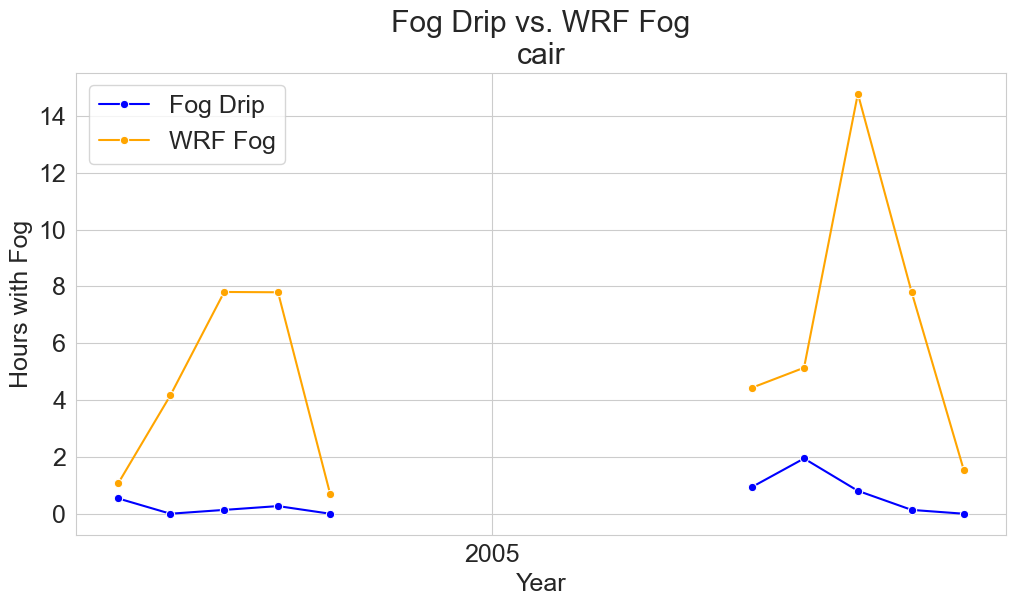

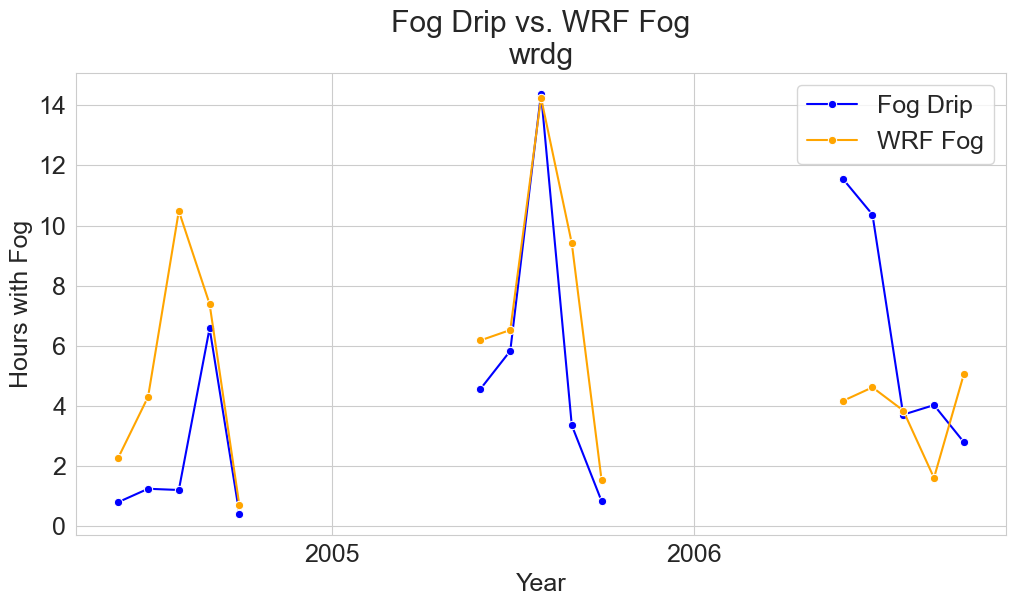

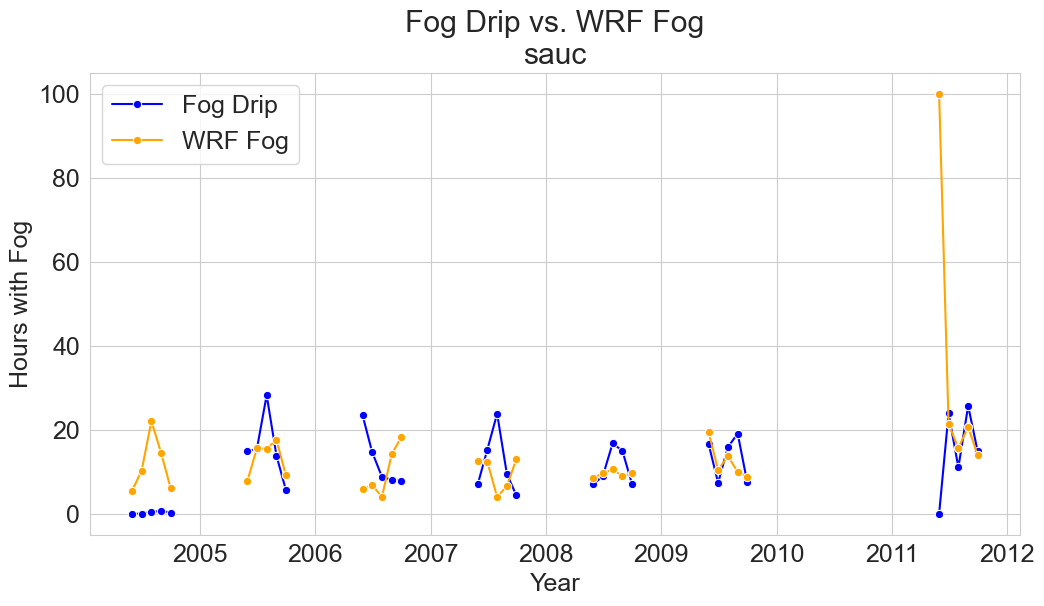

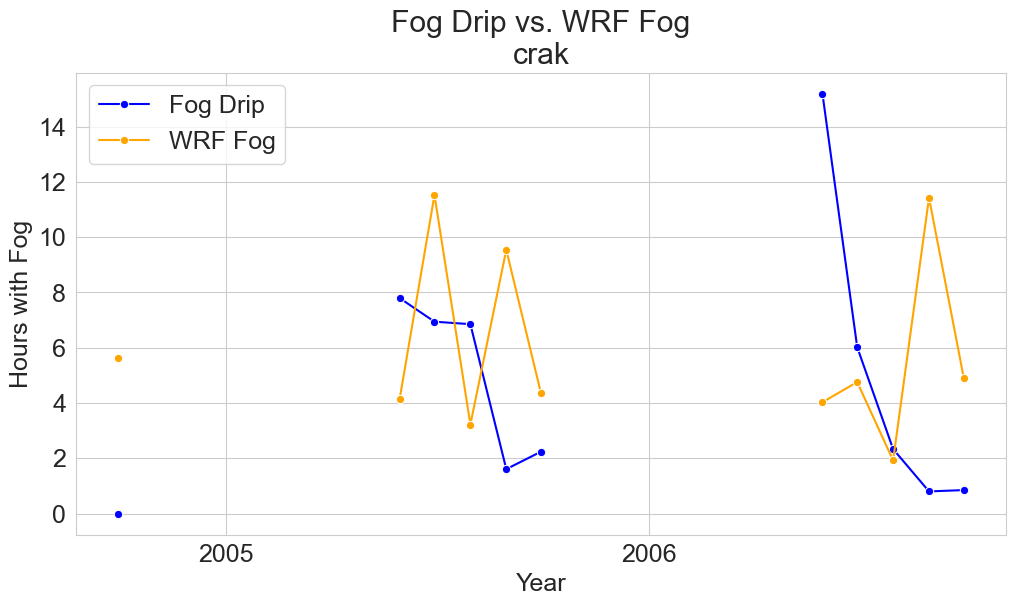

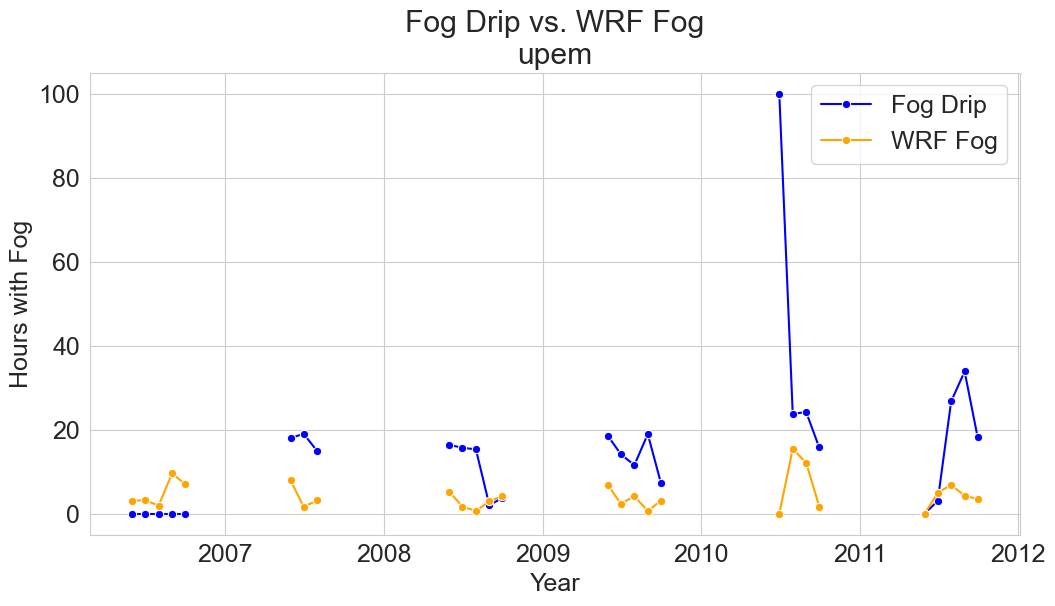

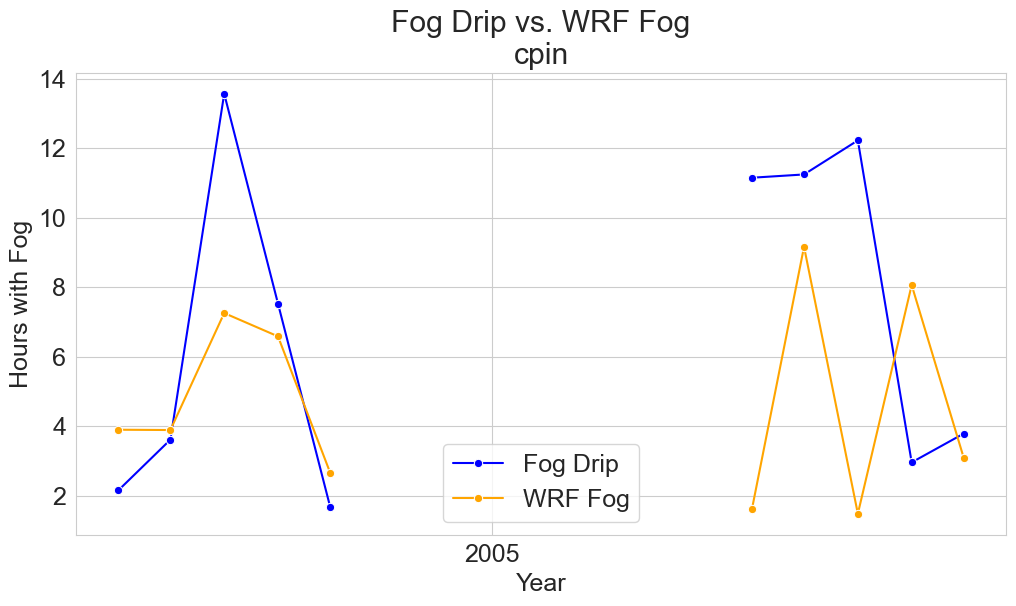

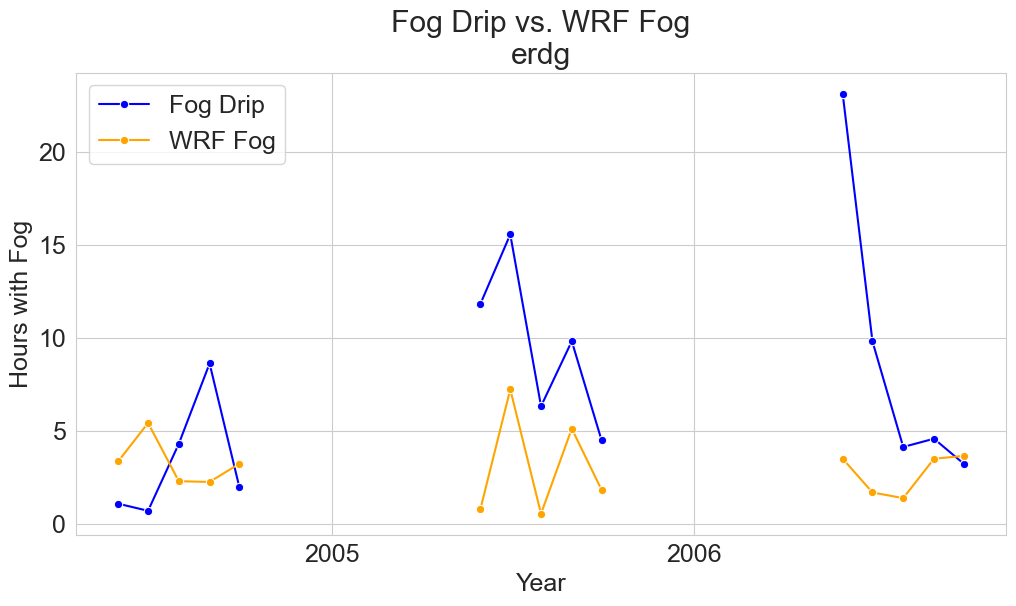

In [19]:
# Aggregate to months/years
df_gp = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PST)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PST)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp.reset_index()

for site in site_order:
    site_df_gp = df_gp.loc[df_gp['site'] == site]

    fig, ax = plt.subplots(figsize=(12,6))
    display_legend=True
    for _, group in site_df_gp.groupby(site_df_gp['time (PST)'].dt.year):
        sns.lineplot(data=group, x='time (PST)', y='fog-binary', marker='o', color='blue', label='Fog Drip', legend=display_legend)
        sns.lineplot(data=group, x='time (PST)', y='wrf-fog-binary', marker='o', color='orange', label='WRF Fog', legend=display_legend)
        display_legend=False
    ax.set(title=f'Fog Drip vs. WRF Fog\n{site}',
        xlabel='Year',
        ylabel='Hours with Fog')

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.show()

# Confusion Matrix Comparison
This compares specific observations, which may be more specific than we need. 

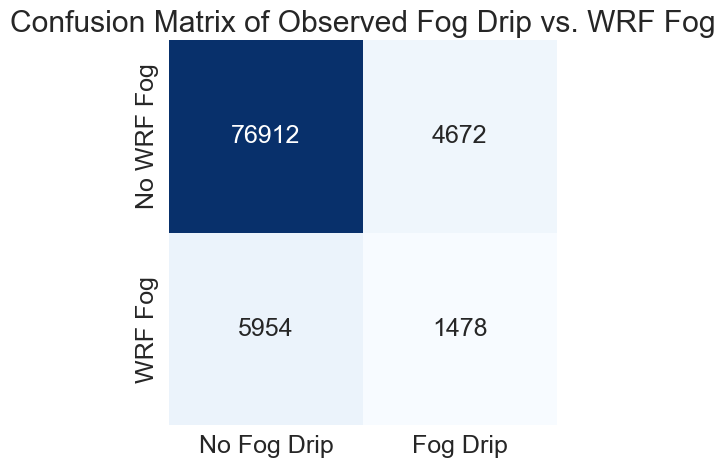

In [20]:
fig, ax = plt.subplots(figsize=(5,5))
cm = confusion_matrix(join_df['fog-binary'], join_df['wrf-fog-binary'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Fog Drip', 'Fog Drip'], yticklabels=['No WRF Fog', 'WRF Fog'], ax=ax)
ax.set(title='Confusion Matrix of Observed Fog Drip vs. WRF Fog')

# Show the plot
plt.show()